In [3]:
# 구글 마운트 해주세요

In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image_path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/copy.png'

In [5]:
image_path

'/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/copy.png'

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
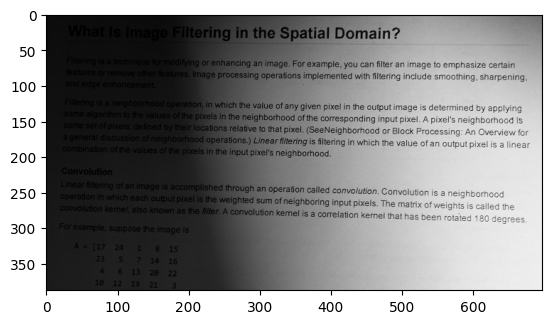

In [6]:
cv2.imread(image_path)

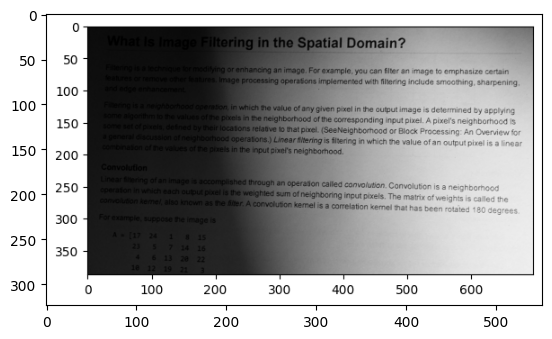

In [7]:
image = cv2.imread(image_path)
plt.imshow(image)
plt.show()

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
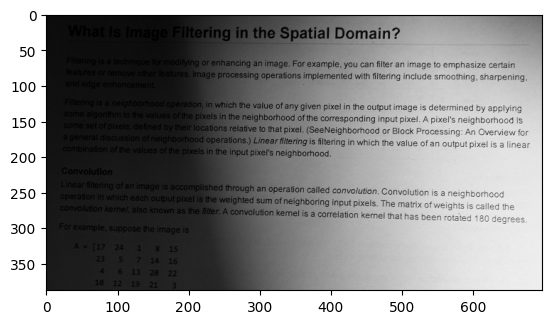

In [8]:
# 이진화 : 흑백(0, 255) 채널로 이미지 변경
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

In [9]:
# 임계값 (threshold)
cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

(50.0,
 array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8))

50.0


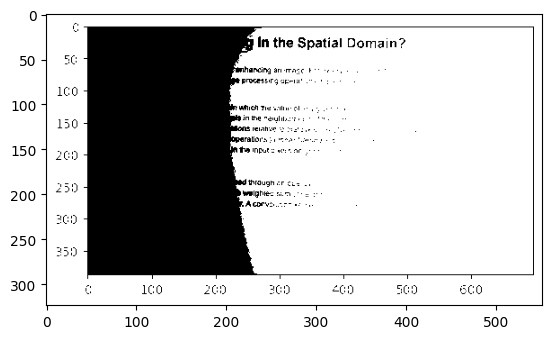

In [10]:
result, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
print(result) # 50
# 50: threshold 임계값 50부터 어두우면 0(검정), 밝으면 255(흰색)
plt.imshow(binary, cmap='gray')
plt.show()

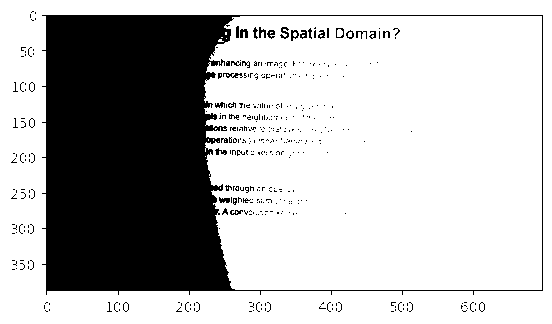

In [11]:
cv2_imshow(binary)

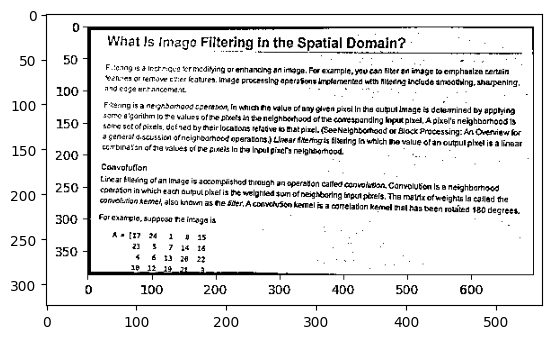

In [12]:
# 적응형 이진화
# >> 영역(region)마다 다른 임계값 사용하겠다는 의미
# (cf) 일반적으로 이진화라 하면 동일 기준 사용

# 단계
# (11*11) 커널 가져와요. 주변 픽셀 값 가져와요.
# (옵션) cv2.ADAPTIVE_THRESH_GAUSSIAN_C 활용, 주변 픽셀에 가우시안 평균(가중 평균) 적용, 평균 계산
# 여기서 나온 평균값에서 상수 (4)를 뺀 값을 threshold T 로 사용
# 픽셀 값이 T 보다 크면 >> 흰색(255), 작으면 >> 검정색(0)
# C 상수 : 값이 크면 >> threshold 낮아짐 >> 더 밝게 잡힘
# 어디에 사용하나요? 로봇 라인트레이싱, OCR, 자동차번호판 인식 (조명변화에 강해요)

binary_ad =\
cv2.adaptiveThreshold(
    gray,  # 적용할 이미지
    255,   # 최대값
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    # 옵션(적응형 판단기준) 주변 픽셀의 가중평균(가우시안)
    cv2.THRESH_BINARY,
    # 주어진 조건(threshold 임계치)에 맞으면 결과를 이렇게 해줘(흰색, 검은색)
    11, # 커널 크기(블록 크기, 주변 영역 크기)
    4   # 상수 (평균/가중평균에서 빼는 값)
)

plt.imshow(binary_ad,  cmap='gray')
plt.show()

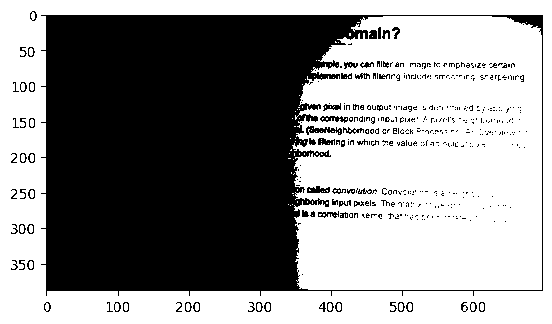

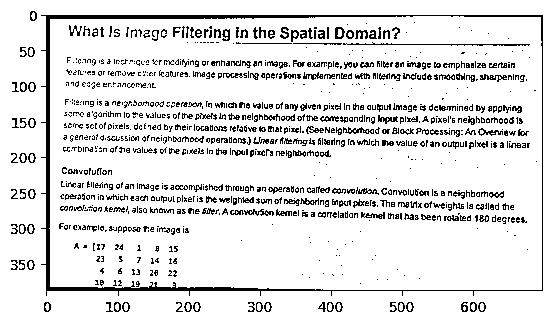

In [13]:
ret, binary_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
binary_ad = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 11, 4)

cv2_imshow(binary_global)  # 검은 부분 생기거나 깨짐
cv2_imshow(binary_ad)      # 글자 / 라인 선명하게 추출

 # 어디까지 전처리 할거냐?
 # 1) 이미지 불러와서 이진화(흑백 변환)
 # 2) 적응형 임계값(threshold)처리

엣지 검출

In [14]:
# sobel filter
# 1차 미분, slope(gradient)
# 영상의 밝기 변화량(gradient)계산 >> 물체 윤곽선(contour), 경계(edge)추출하는 필터
# 밝기가 급격하게 변하네 >> edge(경계)네 (vs) 변화가 없네 >> 배경이네
# >> 경계의 방향과 강도 계산

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
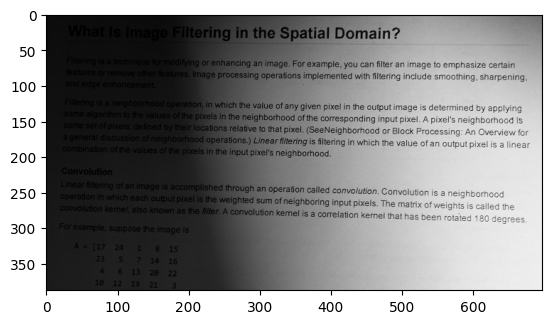

In [15]:
image

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
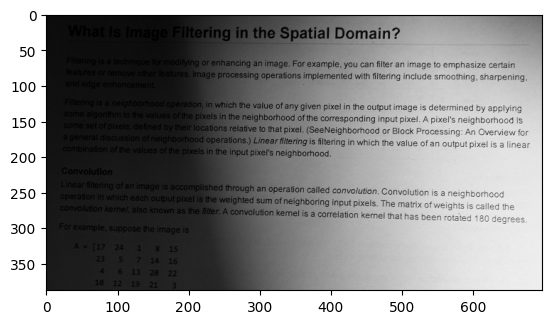

In [16]:
gray

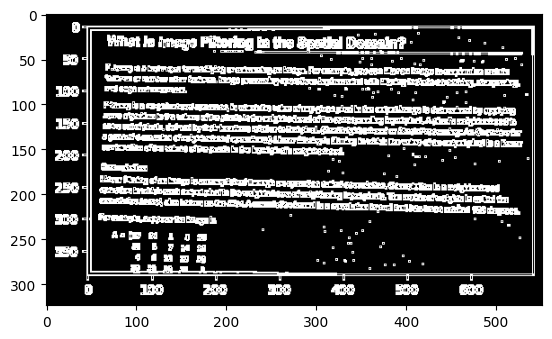

In [17]:
# sobel filter 적용
# 1, 0 >> 수평 엣지, 0, 1>> 수직 엣지
# ksize : kernel size

gx = cv2.Sobel(binary_ad, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(binary_ad, cv2.CV_32F, 0, 1, ksize=3)

# binary_ad : 적응형 이진화 거친 이미지 가져와요
# gx(x방향) 가로 변화 감지 >> 세로선 찾기
# >> dx = 1 x축 방향으로 미분 / dy = 0 y축 방향으로 미분 안해(수직엣지)
# gy(y방향) 세로 변화 감지 >> 가로선 찾기
# >> dx = 0 x축 방향으로 미분 안해 / dy = 1 y축 방향으로 미분(수평엣지)
# cv2.CV_32F: 32 비트 실수형(실수는 음수도 포함하잖아요 >> 정밀하게 계산할거야)
# cf. uint8 (일반이미지)  openCV, matplotlib가 일반이미지로 인식(0-255)

# 필터를 사용하여 엣지의 강도 추출
mag = cv2.magnitude(gx, gy)
# print(mag)

# 피타고라스 정리 활용 >> 전체 엣지 강도 계산 mag = sqrt(gx^2 + gy^2)
# l2 norm 적용
# gx(x방향 기울기, 밝기 변화량), gy(y방향 기울기, 밝기 변화량)
# >> 경계의 방향은 상관없어요. 얼마나 강한 경계(edge) 있는지 계산해요

mag = np.uint8(np.clip(mag, 0, 255))
# np.clip(mag, 0, 255)
# mag 부분을 이미지로 표현 [0,255] 범위로 표현하도록 강제
plt.imshow(mag, cmap='gray')
plt.show()

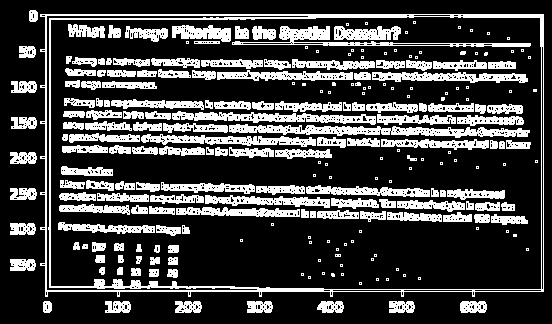

In [18]:
cv2_imshow(mag)

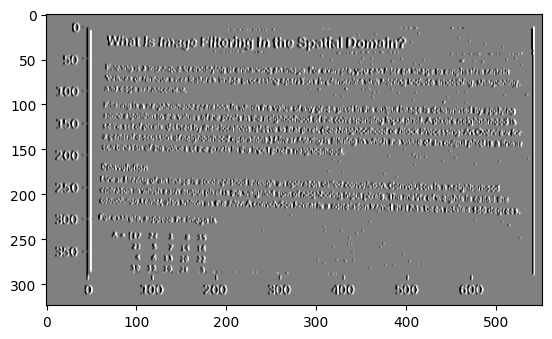

In [19]:
plt.imshow(gx, cmap='gray')
plt.show()

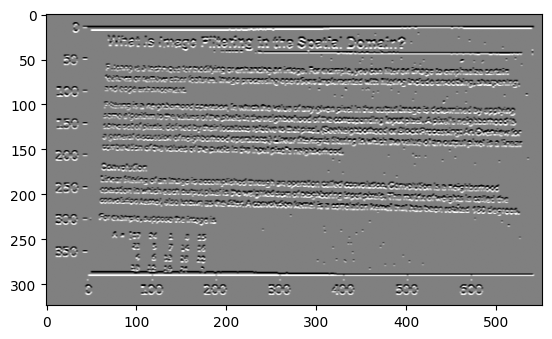

In [20]:
plt.imshow(gy, cmap='gray')
plt.show()

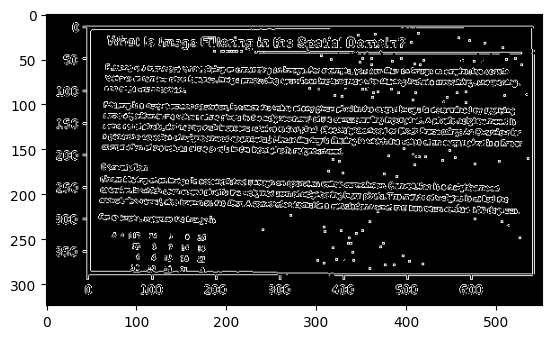

In [21]:
# Canny filter (적용할 이미지, 낮은 임계값, 높은 임계값)
result = cv2.Canny(binary_ad, 30, 200)
# 30 : 낮은 임계값(약한 엣지)
# 200: 높은 임계값(강한 엣지)
# 3-200 사이 구간에 있는 값 (강한엣지와 연결되면 살아남음)
plt.imshow(result, cmap='gray')
plt.show()

Canny filter 동작방식

1. 노이즈 제거(Gaussian Blur)
2. 그래디언트 계산(Sobel Filter)
3. 비최대 억제(Non-Maximum Suppression) : 엣지의 방향을 따라 로컬의 최댓값만 남기고 나머지는 억제
4. 이중 임계값 처리(Double Thresholding) : 강한 엣지, 약한 엣지를 파악하여 약한 엣지는 강한 엣지와 연결되었을 때만 보존
5. 강한 엣지와 연결되지 않은 약한 엣지는 제거

코너(모서리) 검출 알고리즘
- 해리스코너(코너) 알고리즘
- 시-토마스 알고리즘

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
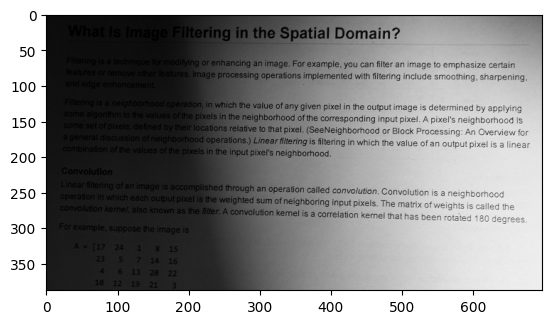

In [22]:
gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
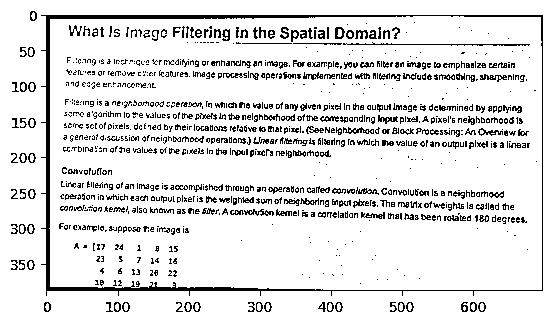

In [23]:
binary_ad

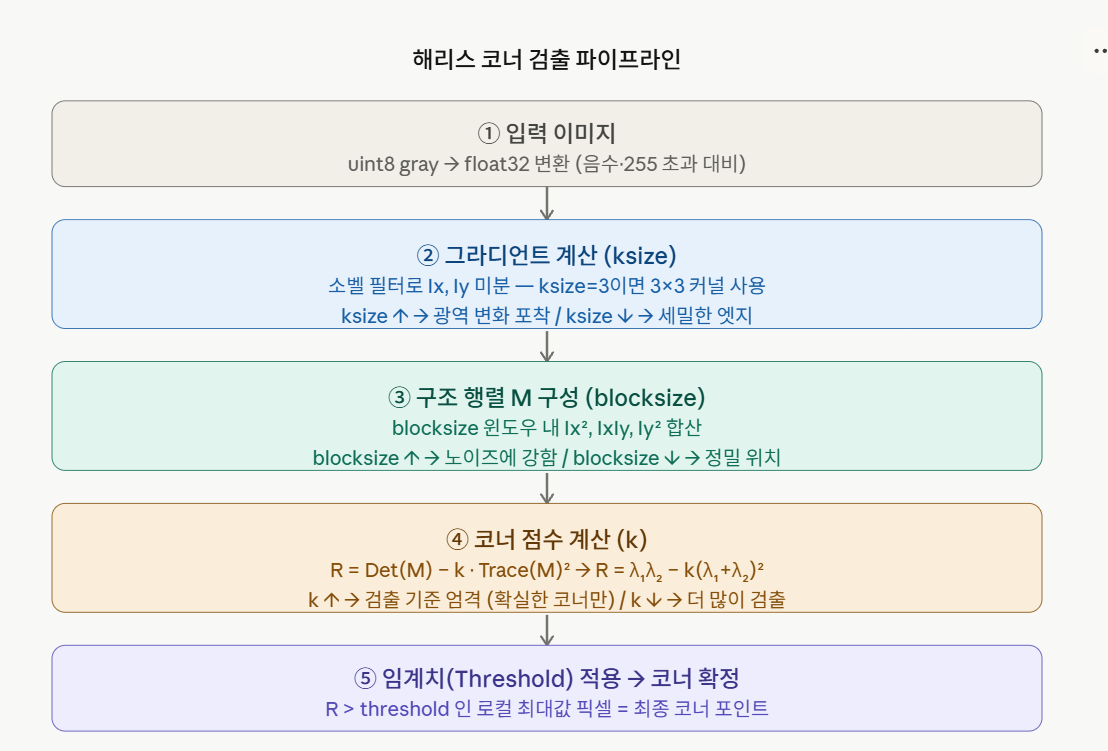

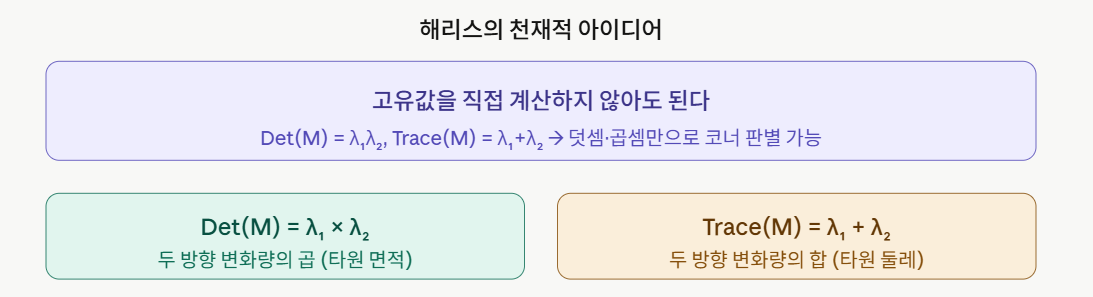

파이프라인 5단계
1. float32 변환(미분해야 하니깐)
2. sobel filter (미분한다 뭐로? ksize로)
3. 구조행렬 M (blocksize 주변영역 고려)
4. R점수 계산 (k)
5. 임계치(threshold) 필터링

궁극적으로 R점수로 판별 (threshold 와 비교해서)
1. R=threshold 평탄한 영역
2. R>threshold 많이 검출 (k)
3. R<threshold 적게 검출

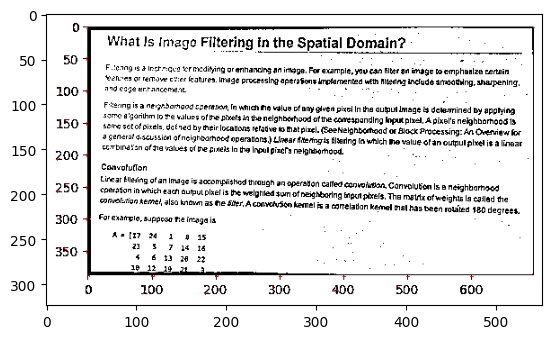

In [24]:
# 해리스 코너 검출
# 윈도우(이미지를 위로 훝으면서 지나가는 작은 사각형: 검사 영역)를 모든 방향으로 움직였을 때,
# 픽셀 값의 변화가 가장 큰 지점을 코너로 생각함

harris = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
# harris

# 모서리 찾기란?
# 코너나 두 방향으로 모두 강한 밝기 변화량이 존재하는 곳 (특징점 추출)
# 코너(선과 선이 교차하는 곳) 저기가 코너일 가능성이 얼마나 높지?
# 점수(score) 맵(map)
# score 가 높으면 코너일 가능성이 높음

# np.float32(gray) : gradient 계산(미분) uint8 >> float32
# blocksize=2 (2*2) 주변 영역 검사
# >> 코너 점(point) 계산할 때 고려하는 주변 영역 크기
# ksize sobel filter 커널 사이즈(3*3) 기울기(gradient) 계산
# k = 0.04 민감도(threshold 임계치) 조절 (0.04-0.06)
# 클수록 더 민감하게 반응 >> 코너가 더 많이 검출

# 정규화
# 검출 결과를 0-255 범위로 정규화 (uint8)
# 왜 정규화해요?
# >> 해리스 검출 결과가 점수 맵(score map)이기 때문에
# (값 범위가 매우 크거나 음수가 될 수가 있기 때문에 0-255로 압축 표현)
harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# harris_norm = (harris-min(harris)) / (max(harris) - min(harris)) * 255
# 여기서 None은 결과값을 임시 배열로 저장하지 않고 cv2.normalize 함수 반환값으로 받겠다는 의미

corner = cv2.cvtColor(binary_ad, cv2.COLOR_BGR2RGB)
# print(corner)

corner[harris_norm > 0.5*harris_norm.max()] = (255,0,0)
# 상위 50% 이상 높은 점수를 받은 코너 점들만 골라서(True) 빨간색으로 표현해

plt.imshow(corner)
plt.show()


goodFeaturesToTrack
- 해리스코너를 개선한 알고리즘

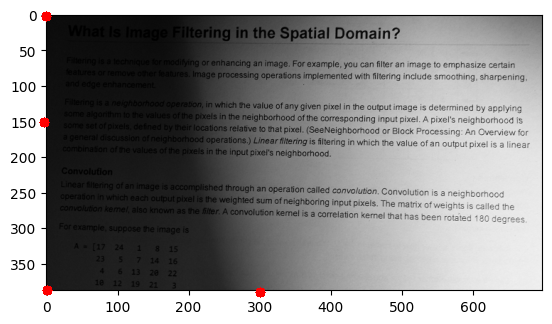

In [25]:
# 흑백 변환 >> 알고리즘 적용 >> 시각화

src = cv2.imread(image_path)
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # 흑백 변환

# 알고리즘 적용: goodFeaturesToTrack
# - 실무용
# - 해리스 코너 : 점수맵(score map) : 사용자가 직접 임계치(threshold) 설정
# - goodFeaturesToTrack 는 해리스코너 점수 계산한 뒤, 점수정렬, 임계치 필터링, 거리 필터링 자동화

# 노이즈 제거하기 위해 가우시안 블러 처리 추가
gray_gauss = cv2.GaussianBlur(gray, (5,5), 0)

# 추적하기 좋은 특징점 찾기
# - 내부적으로 NMS (비최대치 억제) 수행
# - 가장 확실한 점 몇 개만 딱 골라줘.
pts = cv2.goodFeaturesToTrack(gray_gauss,
                              maxCorners=4,      # 최대 100개 특징점
                              qualityLevel=0.01,   # 상위 1%만
                              minDistance=100)      # 특징점 간 최소 거리 10px

# print(pts)
# pts의 결과가 3차원 배열
if pts is not None:
    pts = np.int64(pts)
    for i in pts:
        x, y = i.ravel()  # 3차원 >> 1차원
        cv2.circle(src, (x,y), 5, (0,0,255), -1)

# 시각화 할 때 BGR >> RGB 로 변경
cv2_imshow(src)


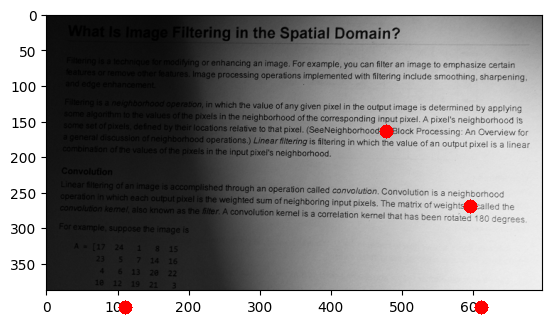

In [26]:
# 흑백 변환 >> 알고리즘 적용 >> 시각화

src = cv2.imread(image_path)
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # 흑백 변환

# 알고리즘 적용: goodFeaturesToTrack
# - 실무용
# - 해리스 코너 : 점수맵(score map) : 사용자가 직접 임계치(threshold) 설정
# - goodFeaturesToTrack 는 해리스코너 점수 계산한 뒤, 점수정렬, 임계치 필터링, 거리 필터링 자동화

# 노이즈 제거하기 위해 가우시안 블러 처리 추가
gray_gauss = cv2.GaussianBlur(gray, (15,15), 0)

binary_ad = cv2.adaptiveThreshold(
    gray_gauss,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    5
)


# 추적하기 좋은 특징점 찾기
# - 내부적으로 NMS (비최대치 억제) 수행
# - 가장 확실한 점 몇 개만 딱 골라줘.
pts = cv2.goodFeaturesToTrack(binary_ad,
                              maxCorners=4,      # 최대 4개 특징점
                              qualityLevel=0.01,   # 상위 1%만
                              minDistance=100)      # 특징점 간 최소 거리 100x

# print(pts)
# pts의 결과가 3차원 배열
if pts is not None:
    pts = np.int64(pts)
    for i in pts:
        x, y = i.ravel()  # 3차원 >> 1차원
        cv2.circle(src, (x,y), 7, (0,0,255), -1)

# 시각화 할 때 BGR >> RGB 로 변경
cv2_imshow(src)


허프변환 (Hough Transform)
- 직선 검출 가능
- 원 검출 가능

In [27]:
np.around(1.54).astype(np.uint8)

np.uint8(2)

In [28]:
path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/water_coins.jpg'

array([[[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [245, 250, 249],
        [246, 251, 250],
        [246, 251, 250]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       ...,

       [[205, 214, 211],
        [224, 233, 230],
        [225, 234, 231],
        ...,
        [242, 247, 245],
        [242, 247, 245],
        [242, 247, 245]],

       [[199, 208, 205],
        [218, 227, 224],
        [220, 229, 226],
        ...,
        [241, 246, 244],
        [241, 246, 244],
        [241, 246, 244]],

       [[193, 202, 199],
        [212, 221, 218],
        [215, 224, 221],
        ...,
        [240, 245, 243],
        [240, 245, 243],
        [240, 245, 243]]], dtype=uint8)
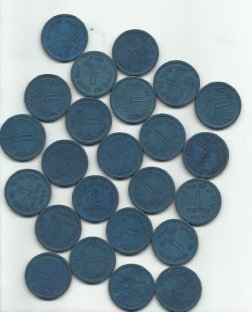

In [29]:
# 이미지 로드

image = cv2.imread(path)
image

In [30]:
image.shape

(312, 252, 3)

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
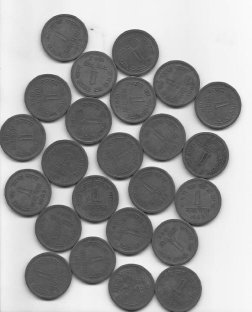

In [31]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

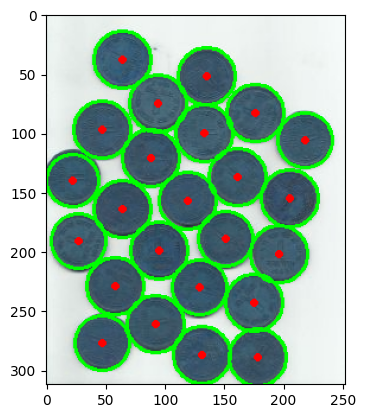

In [32]:
# 원(동전) 검출
circles =\
cv2.HoughCircles(gray,                 # 이진화된 이미지(흑백)
                 cv2.HOUGH_GRADIENT,   # 기울기 사용>>원을 찾겠다
                 dp=1.2,               # 해상도 scaling 비율(1.0 입력 이미지와 같은 해상도)
                                       # >> (값이 크면 속도가 빨라짐, 정확도(성능)은 떨어짐)
                 minDist=30,          # 검출된 원(중심) 사이 최소 거리
                                       # >> 원 중심 간 간격이 30 이하 >> 중복이 아니다
                 param1=100,           # 높은 임계값(canny edge upper threshold)
                 param2=30,            # 투표(voting) 누적된 임계값 (원이라고 판단할 기준)
                 minRadius=10,         # 최소 반지름
                 maxRadius=50          # 최대 반지름
                 )

# 투표(voting) 많은 점(pts)이 원을 지지하면 원으로 인정

if circles is not None:
    circles = np.around(circles).astype(np.uint16)

    for (x,y,r) in circles[0,:]:
        # 원그림에서 배열의 첫번째 차원(1) 무시
        # circles.shape 3차원 배열 (1, N, 3) >> 무시하면 2차원 (N,3)
        # 허프 변환 결과물은 항상 (1,N,3) (N, 검출된 원 개수)
        # 왜 맨 앞 차원은 항상 1인가?  OpenCV 첫번째 차원 비워둬요(여러장을 동시 처리할 지 모르니깐)
        # 지금 한 장만 처리하니깐 무조건 [0] 번 인덱스 고정
        # [0,:] 의미는? 불필요한 첫번째 차원 안써 >> [N, 3] (2차원 list로 변경)
        # 3 은 x(중심점 x),y(중심점 y),r(반지름) 정보
        # 여기서 첫번째차원(1) 항상 크기가 1 (배치가 1인것과 유사)
        # 세번째 차원(3) 3가지 정보(0: 원의 중심 x좌표, 1: 원의 중심 y좌표, 2: 원의 반지름 r)
        # 검출된 모든 원(n개) 정보만 선택

        cv2.circle(image, (x,y), r, (0, 255, 0), 2)
        cv2.circle(image, (x,y), 2, (255, 0, 0), 2)

plt.imshow(image)
plt.show()

In [33]:
# minDist=30,
# 검출된 원(중심) 사이 최소거리
# >> 원 중심간 간격이 30 이상 >> 중복 아니다(별개의 원이라 인정하겠다)
# >> 목적: 과잉 검출 방지
# 30 pixel 거리 이내 다른 원의 중심을 허용 하지 않겠다.
# 즉, 하나의 원에 대한 하나의 검출 결과만 보장한다

# 값이 작으면 서로 가까운 원들을 개별적인 원으로 검출 >> 비슷한 원 여러개가 잡힘
# 값이 크면 원이 너무 멀리 떨어진 경우에만 검출

# param2 = 30,
# 투표(voting) 누적 임계값(원이라고 판단할 기준)
# 값이 높으면 (누가봐도) 원이야 하는 확실한 원만 검출
# 값이 낮으면 (아닌거 같은데) 약한 원도 검출

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
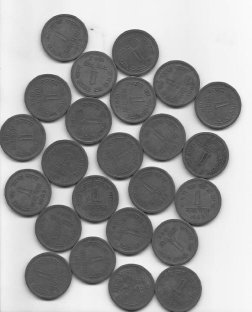

In [34]:
gray

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
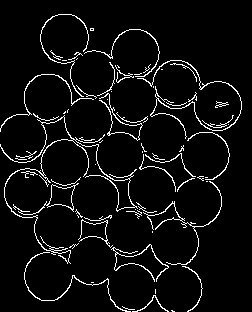

In [35]:
# canny edge 검출
edges = cv2.Canny(gray, 50, 150)
edges
# edge 있으면 255(흰색), 없으면 0(검정)

ρ = x*cos (θ) + y*sin (θ)

확률적 직선 검출

In [36]:
# 확률적 직선 검출
# 이미지 edge(경계) 에서 직선(line)들을 자동 검출하는 알고리즘
# >> 실제 길이 선분 형태로 반환(실무)
# >> 시작점(x1, y1)과 끝점(x2,y2) 좌표로 이루어진 배열 출력

# cf.  cv2.HoughLines 무한 직선 형태
# HoughLinesP : P (probability) 확률

path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/water_coins.jpg'

image = cv2.imread(path)

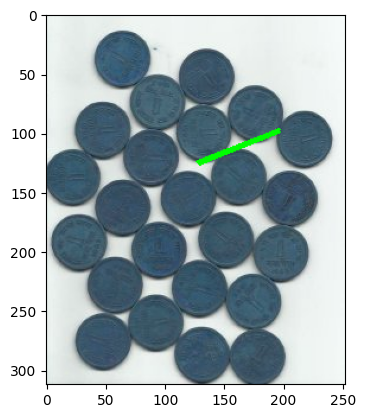

In [42]:
from cv2.gapi import threshold
# 흑백 변환 >> 엣지 검출 >> 직선 검출

# 흑백 변환
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 엣지 검출
edges = cv2.Canny(gray, 50, 150)

# 확률적 직선 검출
lines =\
cv2.HoughLinesP(
    edges,              # canny edges에서 검출된 edges
    rho=1,              # 해상도(거리) 1: 1픽셀 단위(촘촘, 정밀) 10:(듬성듬성)
    theta=np.pi/180,    # 해상도(각도) 180(phi) np.pi/180 = 1degree 단위
    threshold=10,       # 직선으로 간주될 수 있는 최소값(임계치=최소투표수)
                        # 최소 몇 개의 엣지 픽셀이 있어야 직선으로 인정할게
    minLineLength=50,   # 내가 검출하고자 하는 직선의 최소 길이
                        # >> 총 길이가 50 픽셀도 안되 >> 버려
    maxLineGap=10       # 직선으로 간주되는 간격(최대 허용 간격)
                        # >> 끊어진 점들을 어디까지 같은 선으로 인정해줘
)

# lines.shape
# (1, 1, 4) (N,1,4) 3차원 배열, 4: (시작점: x1,y1, 끝점: x2, y2)

# 시각화
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(image)
plt.show()

# rho : 원점(0,0)에서 직선까지 거리 (1px 단위로 매우 정밀하게 계산한다)
# theta : 각도 단위(radian)
# >> np.pi/180 = 1도(degree)
# >> 각도 resolution이 크면,직선 검출 정확도 떨어짐
# threshold=10, # 직선으로 간주될 수 있는 최소값(최소 투표수 10)
# >> 누적 투표수가 10 이상 되어야 선이라고 간주
# >> 높이면 확실한 직선만 검출 (노이즈 적어져요), 낮추면 작은 선들도 다 검출
# minLineLength=10,  # 내가 검출하려는 직선의 최소 길이(길이가 10 px 미만 >> 무시)
# maxLineGap=10)     # 직선으로 간주되는 간격(직선 간격 허용)
# >> 중간에 끊어져 있는 선이 있어요. 선들 간의 사이가 10이하면 연결된 하나의 선으로 간주

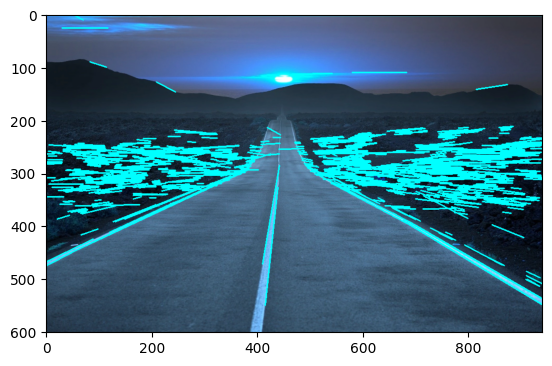

In [43]:
line_path ='/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/lines.png'

image = cv2.imread(line_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=10,
    maxLineGap=10
)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1, y1), (x2, y2), (0,255,255), 2)

plt.imshow(image)
plt.show()

컨투어(contour, 윤곽선) 검출

OTSU : 자동으로 최적 임계값 찾기
- grayscale image >> 이진화 하는 코드
- 단계
  1. 히스토그램(픽셀 값 분포) 자동으로 분석
  2. 최적의 임계값(threshold) 찾기
  3. 이미지 내부에서 흑(0), 백(255) 나눠줘요
- 문서 스캔, OCR

In [50]:
path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/data/water_coins.jpg'

In [51]:
image = cv2.imread(path)

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
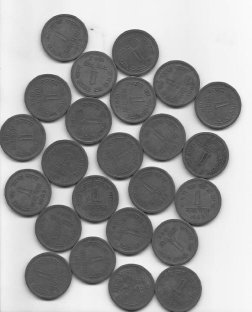

In [52]:
# 흑백 >> 임계값으로 컨투어(윤곽선) 추출
cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [53]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 임계값 적용
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

# '_' threshold (안 쓴다)
# 왜? 의미 없다. otsu가 자동으로 최적값 찾아주니깐

In [58]:
# 컨투어 검출
# cv2.RETR_EXTERNAL 윤곽선 찾아내는 방법
# cv2.CHAIN_APPROX_SIMPLE  윤곽선을 저장하는 방법

cons = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
# print(cons)
print(len(cons))
# binary : 임계값 적용해서 나온 이진화된 이미지
# cv2.RETR_LIST : (retrieve list 목록을 검색하다) (모든 윤곽선 검색해 봐요)
# cv2.CHAIN_APPROX_NONE 모든 점 저장
# 흰색(255) 영역의 경계선 찾아요 >> 리스트 형식으로 반환

con_packs = cons[0] if len(cons) == 2 else cons[1]
#  len(cons) == 2 버전이 4.x 이면 cons[0] 입력이미지 (윤곽선 리스트 포함)
# print(con_packs)

2


- openCV 3.X  
  - 결과값을 3개 반환(입력 이미지, 윤곽선 리스트, 계층구조)
- openCV 4.X
  - 결과값을 2개 반환(입력 이미지, 계층구조)

In [60]:
cons[:1][0]

(array([[[153, 299]],
 
        [[152, 300]],
 
        [[151, 301]],
 
        [[150, 302]],
 
        [[149, 303]],
 
        [[149, 304]],
 
        [[148, 305]],
 
        [[147, 306]],
 
        [[146, 307]],
 
        [[145, 308]],
 
        [[144, 308]],
 
        [[143, 309]],
 
        [[142, 310]],
 
        [[141, 310]],
 
        [[140, 311]],
 
        [[139, 311]],
 
        [[138, 311]],
 
        [[139, 311]],
 
        [[140, 311]],
 
        [[141, 311]],
 
        [[142, 311]],
 
        [[143, 311]],
 
        [[144, 311]],
 
        [[145, 311]],
 
        [[146, 311]],
 
        [[147, 311]],
 
        [[148, 311]],
 
        [[149, 311]],
 
        [[150, 311]],
 
        [[151, 311]],
 
        [[152, 311]],
 
        [[153, 311]],
 
        [[154, 311]],
 
        [[155, 311]],
 
        [[156, 311]],
 
        [[157, 311]],
 
        [[158, 311]],
 
        [[159, 311]],
 
        [[160, 311]],
 
        [[161, 311]],
 
        [[162, 311]],
 
        [[163, 3

In [61]:
cons[1]

array([[[ 1, -1, -1, -1],
        [ 2,  0, -1, -1],
        [ 3,  1, -1, -1],
        [ 4,  2, -1, -1],
        [ 5,  3, -1, -1],
        [ 6,  4, -1, -1],
        [ 7,  5, -1, -1],
        [ 8,  6, -1, -1],
        [ 9,  7, -1, -1],
        [10,  8, -1, -1],
        [11,  9, -1, -1],
        [12, 10, -1, -1],
        [13, 11, -1, -1],
        [14, 12, -1, -1],
        [15, 13, -1, -1],
        [-1, 14, -1, -1]]], dtype=int32)

cv2.RETR_LIST
- 윤곽선 검색 방식(contour retrieval mode)
  - RETR_LIST : 모든 윤곽선 찾아서 리스트로 반환
  - RETR_EXTERNAL : 가장 바깥 윤곽선만
  - RETR_TREE : 윤곽선 계층구조까지 (부모-자식)
  - RETR_CCOMP : 2단계 계층구조까지

- cv2.CHAIN_APPROX_NONE
  - 윤곽선의 모든 점을 전부 저장
- cv2.CHAIN_APPROX_SIMPLE
  - 꼭 필요한 점(시작점, 끝점)만 저장

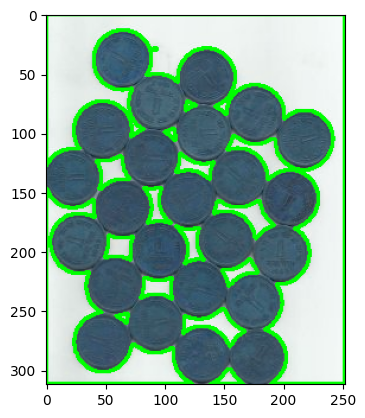

In [62]:
# 시각화
cv2.drawContours(image, con_packs, -1, (0, 255, 0), 2)
# -1 : 모든 윤곽선 그려줘

plt.imshow(image)
plt.show()

In [ ]:
# [정리 시간]
# 1. cv2.moments
# >> moments: 이미지에서 '중심' 어디지? '면적'얼마지? >> 데이터 수치 추출
# 2. cv2.addWeighted : 두 영상이 겹쳐져요. '잔상효과''레이어 쌓기' 등 >> 새로운 이미지 만들어요
# >> dst = w1 * img1 + w2 * img2 + gamma
# 배경 위에 반투명, 투명한 레이어(UI) 올리거나 두 영상을 특징 결합시 사용
# 3. cv2.magnitude (벡터의 크기)
# >> 엣지(경계) 검출, optical flow(광학 흐름)에 자주 사용
# >> 변화의 세기 mag = sqrt(gx^2 + gy^2)
# >> 각 pixel 위치 확인 >> x방향 변화량 + y방향 변화량 합쳐서 '얼마나 강한 경계선(엣지)인가?'

In [ ]:
# binary_ad
# 어디까지 전처리한거야?
# 1) 이미지 불러와서 이진화(흑백 변환)
# 2) 적응형 임계값(threshold) 처리
# 여기까지 전처리 한 이미지(입력값)로 canny 엣지 검출

In [ ]:
# ksize와 blocksize 차이가 뭐예요?
# ksize : 필터, 마스크의 크기 (반드시 홀수만 가능: 중심점 계산해야 하기 때문 좌우/상하 차이구해야함) 3*3, 5*5 등
# blocksize : adaptiveThreshold 같이 적응형 기반 계산 하기 위함 (주변 영역의 이웃의 크기)
# 즉 평균 구할 영역의 크기